# Hotel Booking Cancellation

### Applying 5 Algorithms on 3 Datasets : Logistic Regression, KNN, Decision Tree, Random Forest, CNN

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix


In [2]:
def conf_mat(y_test, y_pred, title="Confusion Matrix"):
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()


---
# Dataset 1: Hotel Booking Demand

In [3]:
df1 = pd.read_csv("/content/Dataset 1.csv")
df1.head()


,hotel,canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,city
0,Resort Hotel - Chandigarh,0,342,2024,July,30,27,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,16:40.9,Chandigarh
1,Resort Hotel - Mumbai,0,737,2024,April,17,28,0,0,2,...,NaN,NaN,0,Transient,0.0,0,0,Check-Out,56:21.5,Mumbai
2,Resort Hotel - Delhi,0,7,2024,September,37,10,0,1,1,...,NaN,NaN,0,Transient,75.0,0,0,Check-Out,46:25.7,Delhi
3,Resort Hotel - Kolkata,0,13,2024,August,33,14,0,1,1,...,304.0,NaN,0,Transient,75.0,0,0,Check-Out,07:10.1,Kolkata
4,Resort Hotel - Lucknow,0,14,2024,September,37,14,0,2,2,...,240.0,NaN,0,Transient,98.0,0,1,Check-Out,27:32.5,Lucknow


In [4]:
print(df1.shape)
df1.info()


(119390, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 33 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   canceled                        119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  mea

In [5]:
# Numeric and categorical feature lists (before dropping)
numeric_features_1 = ['lead_time', 'arrival_date_year', 'stays_in_weekend_nights',
                      'stays_in_week_nights', 'adults', 'children', 'babies',
                      'is_repeated_guest', 'previous_cancellations',
                      'previous_bookings_not_canceled', 'booking_changes',
                      'days_in_waiting_list', 'adr',
                      'required_car_parking_spaces', 'total_of_special_requests']

categorical_features_1 = ['hotel', 'arrival_date_month', 'meal', 'market_segment',
                           'distribution_channel', 'reserved_room_type',
                           'assigned_room_type', 'deposit_type', 'customer_type', 'country']


In [6]:
df1.isnull().sum()


,0
hotel,0
canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [7]:
df1.describe()


,canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.0,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2024.0,26.375835,15.723394,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.0,15.021596,8.805079,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2024.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2024.0,13.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2024.0,26.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2024.0,39.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2024.0,52.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


## Data Cleaning – Dataset 1



In [8]:
# Drop columns: too many nulls, data leakage, or low impact
df1.drop(['company', 'agent', 'reservation_status', 'reservation_status_date',
          'city', 'arrival_date_week_number', 'arrival_date_day_of_month'],
         axis=1, inplace=True)

print("Shape after dropping:", df1.shape)
df1.head()


Shape after dropping: (119390, 26)


,hotel,canceled,lead_time,arrival_date_year,arrival_date_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,...,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel - Chandigarh,0,342,2024,July,0,0,2,0.0,0,...,0,C,C,3,No Deposit,0,Transient,0.0,0,0
1,Resort Hotel - Mumbai,0,737,2024,April,0,0,2,0.0,0,...,0,C,C,4,No Deposit,0,Transient,0.0,0,0
2,Resort Hotel - Delhi,0,7,2024,September,0,1,1,0.0,0,...,0,A,C,0,No Deposit,0,Transient,75.0,0,0
3,Resort Hotel - Kolkata,0,13,2024,August,0,1,1,0.0,0,...,0,A,A,0,No Deposit,0,Transient,75.0,0,0
4,Resort Hotel - Lucknow,0,14,2024,September,0,2,2,0.0,0,...,0,A,A,0,No Deposit,0,Transient,98.0,0,1


In [9]:
# Fill the small number of nulls in 'children' with 0
df1['children'] = df1['children'].fillna(0)

# Fill the nulls in 'country' with the most common country
df1['country'] = df1['country'].fillna(df1['country'].mode()[0])

print("Remaining nulls:")
print(df1.isnull().sum())


Remaining nulls:
hotel                             0
canceled                          0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
assigned_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64


In [10]:
df1.corr(numeric_only=True)


,canceled,lead_time,arrival_date_year,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
canceled,1.000000,0.293123,NaN,-0.001791,0.024765,0.060017,0.005036,-0.032491,-0.084793,0.110133,-0.057358,-0.144381,0.054186,0.047557,-0.195498,-0.234658
lead_time,0.293123,1.000000,NaN,0.085671,0.165799,0.119519,-0.037613,-0.020915,-0.124410,0.086042,-0.073548,0.000149,0.170084,-0.063077,-0.116451,-0.095712
arrival_date_year,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stays_in_weekend_nights,-0.001791,0.085671,NaN,1.000000,0.498969,0.091871,0.045794,0.018483,-0.087239,-0.012775,-0.042715,0.063281,-0.054151,0.049342,-0.018554,0.072671
stays_in_week_nights,0.024765,0.165799,NaN,0.498969,1.000000,0.092976,0.044203,0.020191,-0.097245,-0.013992,-0.048743,0.096209,-0.002020,0.065237,-0.024859,0.068192
adults,0.060017,0.119519,NaN,0.091871,0.092976,1.000000,0.030440,0.018146,-0.146426,-0.006738,-0.107983,-0.051673,-0.008283,0.230641,0.014785,0.122884
children,0.005036,-0.037613,NaN,0.045794,0.044203,0.030440,1.000000,0.024030,-0.032858,-0.024729,-0.021072,0.048952,-0.033271,0.324853,0.056255,0.081736
babies,-0.032491,-0.020915,NaN,0.018483,0.020191,0.018146,0.024030,1.000000,-0.008943,-0.007501,-0.006550,0.083440,-0.010621,0.029186,0.037383,0.097889
is_repeated_guest,-0.084793,-0.124410,NaN,-0.087239,-0.097245,-0.146426,-0.032858,-0.008943,1.000000,0.082293,0.418056,0.012092,-0.022235,-0.134314,0.077090,0.013050
previous_cancellations,0.110133,0.086042,NaN,-0.012775,-0.013992,-0.006738,-0.024729,-0.007501,0.082293,1.000000,0.152728,-0.026993,0.005929,-0.065646,-0.018492,-0.048384


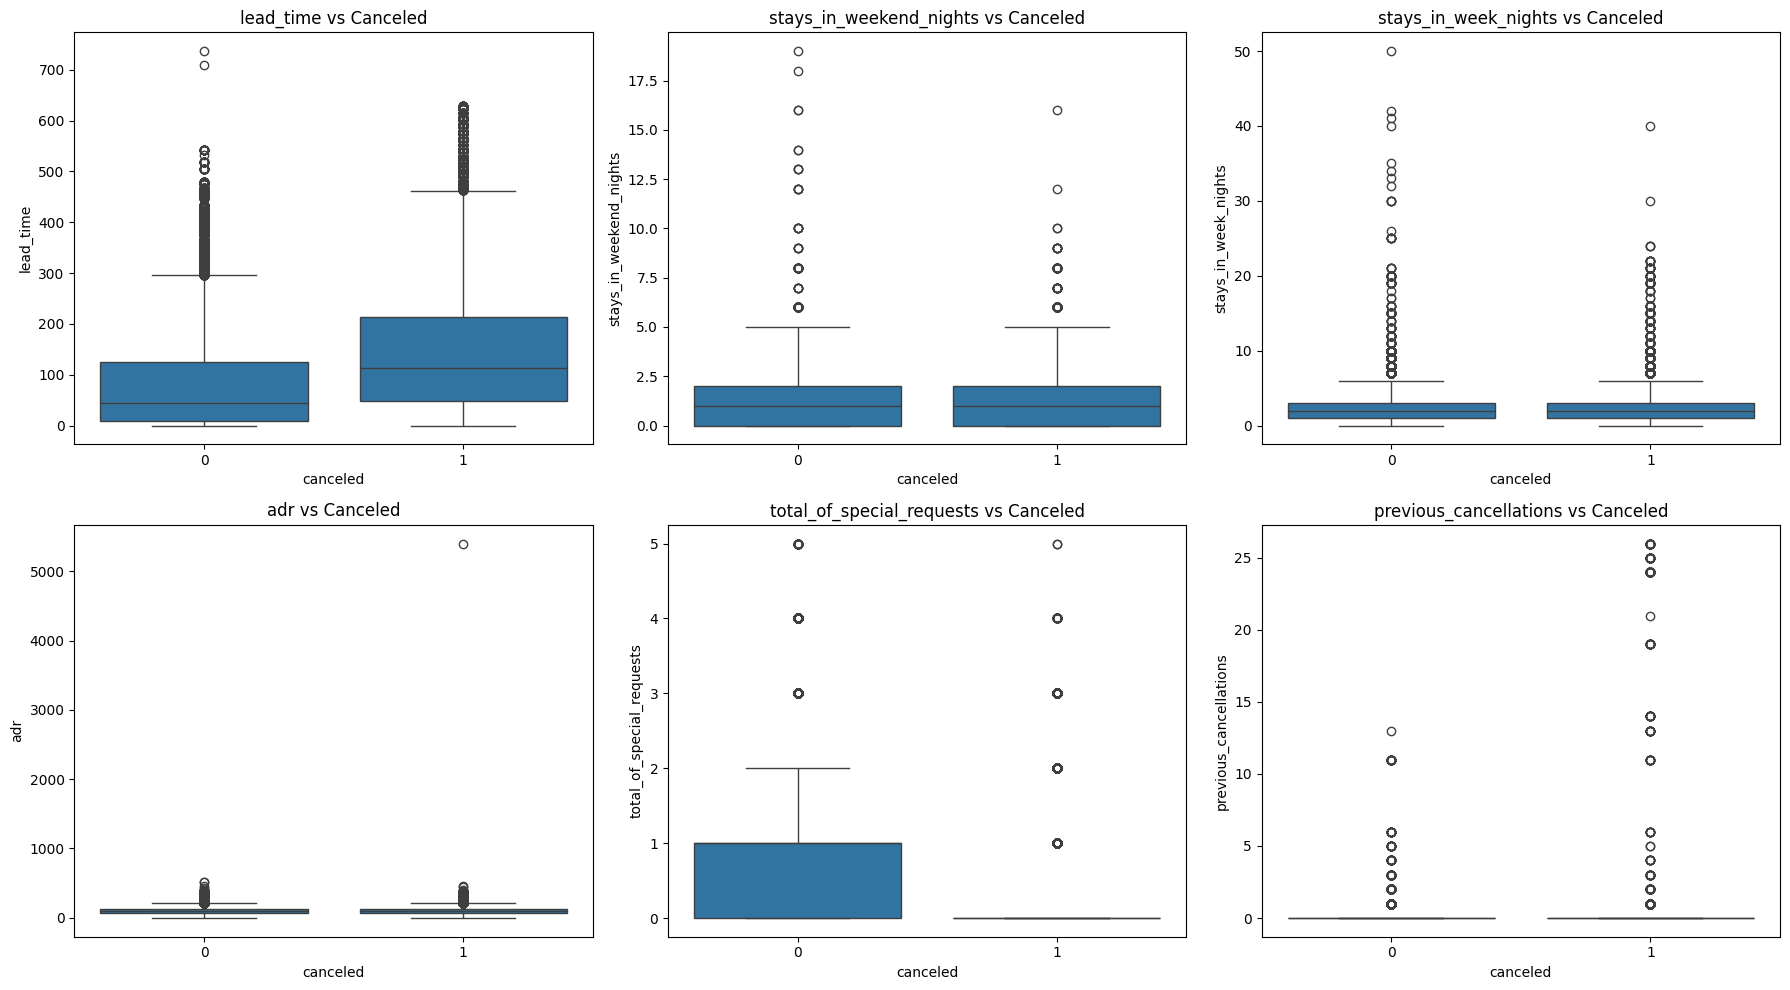

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(['lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
                          'adr', 'total_of_special_requests', 'previous_cancellations']):
    sns.boxplot(x='canceled', y=col, data=df1, ax=axes[i])
    axes[i].set_title(f'{col} vs Canceled')
plt.tight_layout()
plt.show()


IndexError: index 9 is out of bounds for axis 0 with size 9

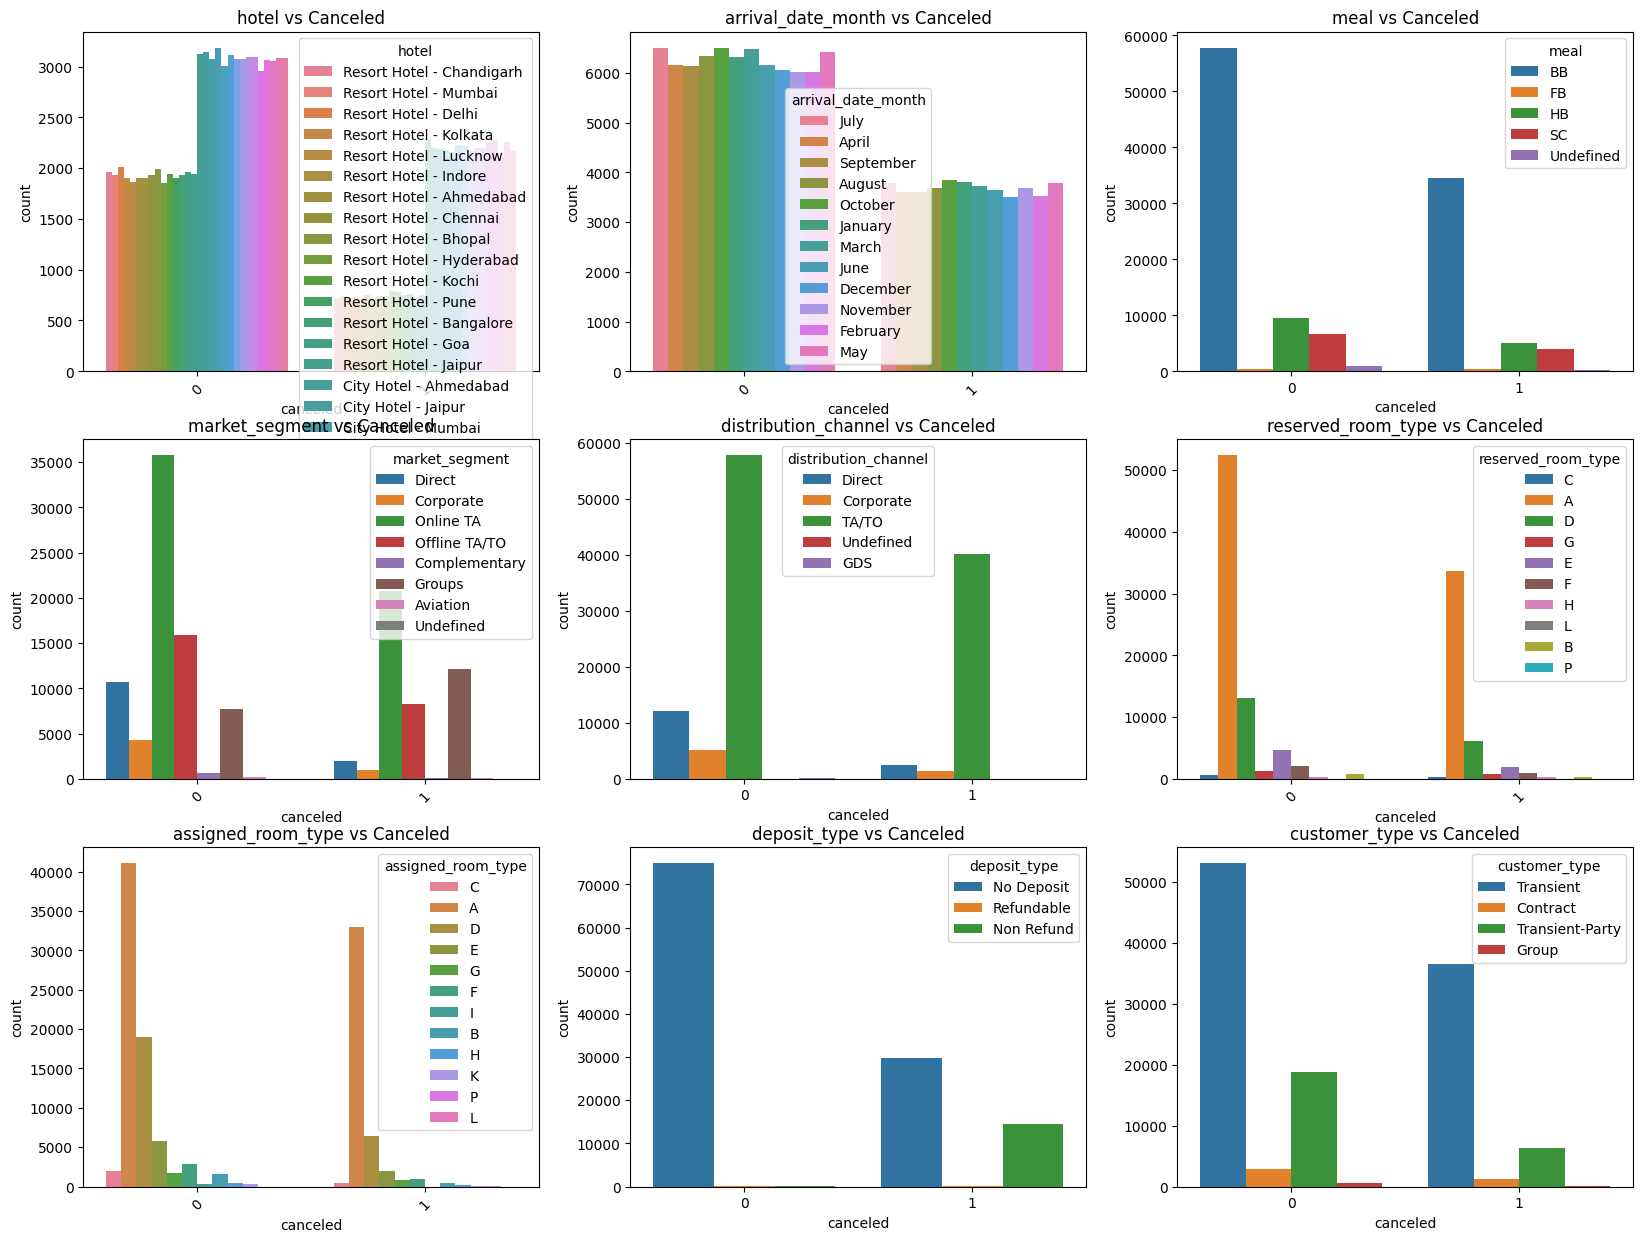

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
axes = axes.flatten()
for i, col in enumerate(categorical_features_1):
    sns.countplot(x='canceled', hue=col, data=df1, ax=axes[i])
    axes[i].set_title(f'{col} vs Canceled')
    if len(df1[col].unique()) > 5:
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [13]:
X1 = df1.drop('canceled', axis=1)
y1 = df1['canceled']


In [14]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42)


In [15]:
for col in numeric_features_1:
    if X1[col].isnull().any():
        X1_train[col] = X1_train[col].fillna(X1_train[col].mean())
        X1_test[col] = X1_test[col].fillna(X1_train[col].mean())

for col in categorical_features_1:
    if X1[col].isnull().any():
        X1_train[col] = X1_train[col].fillna(X1_train[col].mode()[0])
        X1_test[col] = X1_test[col].fillna(X1_train[col].mode()[0])

print("Missing values after fillna:")
print(X1_train.isnull().sum().sum())


Missing values after fillna:
0


In [16]:
scaler1 = StandardScaler()
X1_train[numeric_features_1] = scaler1.fit_transform(X1_train[numeric_features_1])
X1_test[numeric_features_1] = scaler1.transform(X1_test[numeric_features_1])


In [17]:
encoder1 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder1.fit(X1_train[categorical_features_1])

X1_train_encoded = encoder1.transform(X1_train[categorical_features_1])
X1_test_encoded = encoder1.transform(X1_test[categorical_features_1])

encoded_cols1 = encoder1.get_feature_names_out(categorical_features_1)

X1_train_encoded = pd.DataFrame(X1_train_encoded, columns=encoded_cols1, index=X1_train.index)
X1_test_encoded = pd.DataFrame(X1_test_encoded, columns=encoded_cols1, index=X1_test.index)

X1_train = X1_train.drop(columns=categorical_features_1)
X1_test = X1_test.drop(columns=categorical_features_1)

X1_train = pd.concat([X1_train, X1_train_encoded], axis=1)
X1_test = pd.concat([X1_test, X1_test_encoded], axis=1)

print("X1_train shape:", X1_train.shape)
X1_train.head()


X1_train shape: (95512, 277)


,lead_time,arrival_date_year,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,...,country_UMI,country_URY,country_USA,country_UZB,country_VEN,country_VGB,country_VNM,country_ZAF,country_ZMB,country_ZWE
67702,-0.373594,0.0,1.073203,-0.785244,2.001135,-0.260570,-0.084135,-0.180852,-0.102765,-0.090206,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
115851,-0.654357,0.0,0.072971,-0.785244,0.251591,2.251039,-0.084135,-0.180852,-0.102765,-0.090206,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57345,-0.897685,0.0,0.072971,-0.785244,0.251591,4.762648,-0.084135,-0.180852,-0.102765,-0.090206,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11622,1.376493,0.0,1.073203,0.784849,0.251591,-0.260570,-0.084135,-0.180852,-0.102765,-0.090206,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
33333,-0.757303,0.0,0.072971,-0.785244,0.251591,-0.260570,-0.084135,-0.180852,-0.102765,-0.090206,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Logistic Regression – Dataset 1

Confusion Matrix:


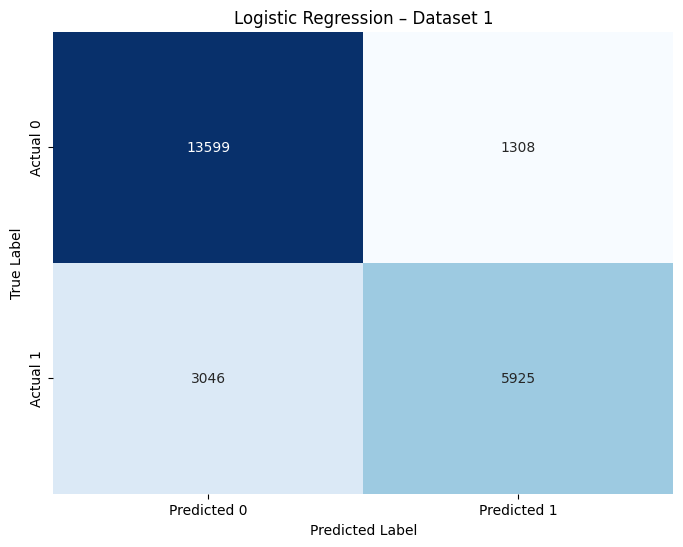

              precision    recall  f1-score   support

           0       0.82      0.91      0.86     14907
           1       0.82      0.66      0.73      8971

    accuracy                           0.82     23878
   macro avg       0.82      0.79      0.80     23878
weighted avg       0.82      0.82      0.81     23878



In [19]:
lr1 = LogisticRegression(max_iter=1000)
lr1.fit(X1_train, y1_train)
y_pred_lr1 = lr1.predict(X1_test)

conf_mat(y1_test, y_pred_lr1, "Logistic Regression – Dataset 1")
print(classification_report(y1_test, y_pred_lr1))


## KNN – Dataset 1

Confusion Matrix:


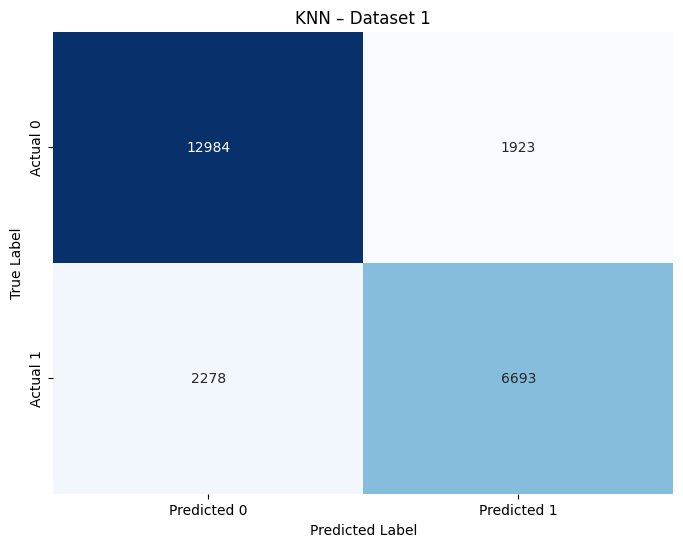

              precision    recall  f1-score   support

           0       0.85      0.87      0.86     14907
           1       0.78      0.75      0.76      8971

    accuracy                           0.82     23878
   macro avg       0.81      0.81      0.81     23878
weighted avg       0.82      0.82      0.82     23878



In [20]:
knn1 = KNeighborsClassifier()
knn1.fit(X1_train, y1_train)
y_pred_knn1 = knn1.predict(X1_test)

conf_mat(y1_test, y_pred_knn1, "KNN – Dataset 1")
print(classification_report(y1_test, y_pred_knn1))


## Decision Tree – Dataset 1

Confusion Matrix:


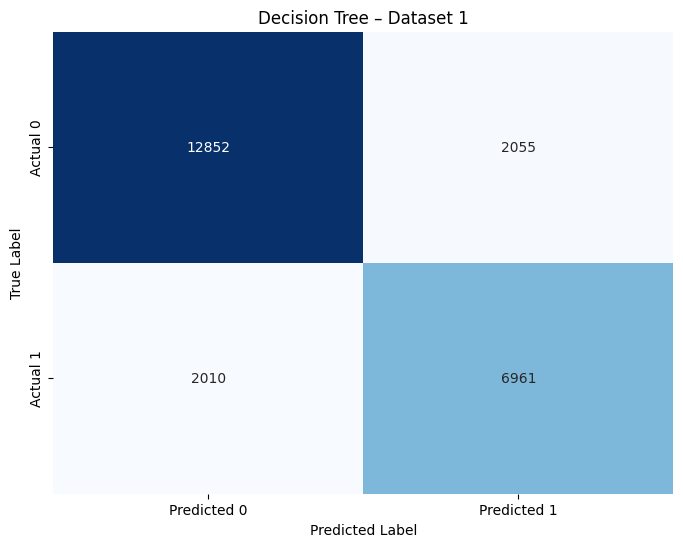

              precision    recall  f1-score   support

           0       0.86      0.86      0.86     14907
           1       0.77      0.78      0.77      8971

    accuracy                           0.83     23878
   macro avg       0.82      0.82      0.82     23878
weighted avg       0.83      0.83      0.83     23878



In [21]:
dt1 = DecisionTreeClassifier(random_state=42)
dt1.fit(X1_train, y1_train)
y_pred_dt1 = dt1.predict(X1_test)

conf_mat(y1_test, y_pred_dt1, "Decision Tree – Dataset 1")
print(classification_report(y1_test, y_pred_dt1))


## Random Forest – Dataset 1

Confusion Matrix:


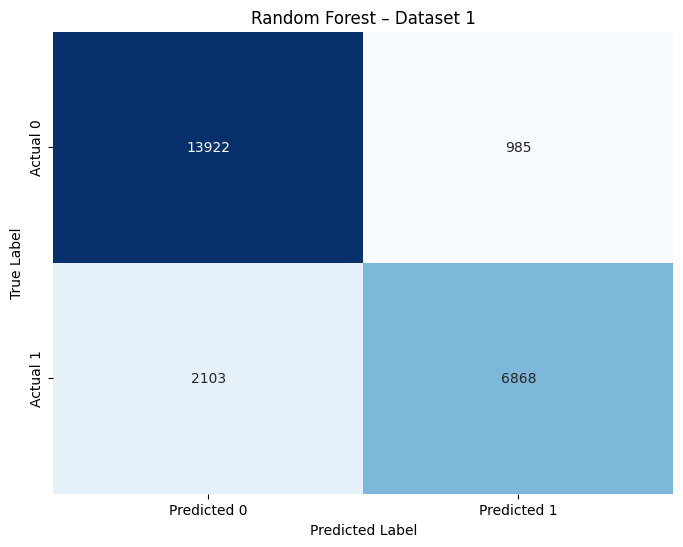

              precision    recall  f1-score   support

           0       0.87      0.93      0.90     14907
           1       0.87      0.77      0.82      8971

    accuracy                           0.87     23878
   macro avg       0.87      0.85      0.86     23878
weighted avg       0.87      0.87      0.87     23878



In [22]:
rf1 = RandomForestClassifier(random_state=42)
rf1.fit(X1_train, y1_train)
y_pred_rf1 = rf1.predict(X1_test)

conf_mat(y1_test, y_pred_rf1, "Random Forest – Dataset 1")
print(classification_report(y1_test, y_pred_rf1))


## CNN – Dataset 1

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 16s 4ms/step - accuracy: 0.8216 - loss: 0.3720
Epoch 2/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8359 - loss: 0.3466
Epoch 3/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8408 - loss: 0.3376
Epoch 4/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8420 - loss: 0.3324
Epoch 5/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8446 - loss: 0.3282
Epoch 6/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8464 - loss: 0.3261
Epoch 7/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 19s 3ms/step - accuracy: 0.8474 - loss: 0.3227
Epoch 8/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8497 - loss: 0.3202
Epoch 9/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8513 - loss: 0.3181
Epoch 10/10
2985/2985 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8511 - loss: 0.3163
747/747 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Confusion Matrix:


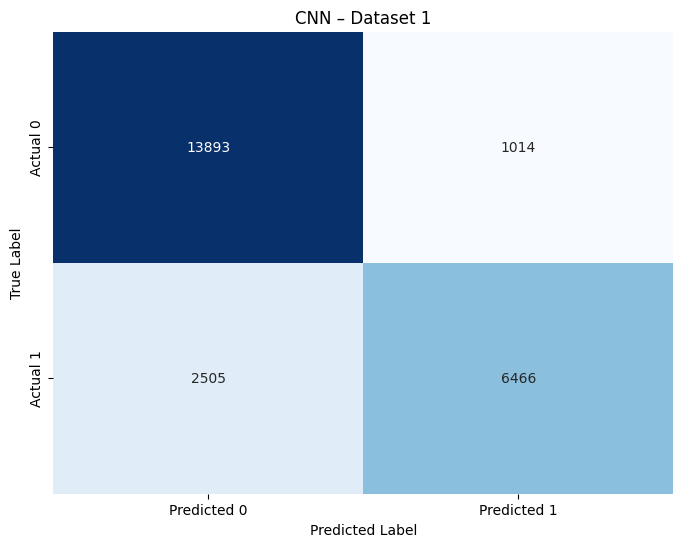

              precision    recall  f1-score   support

           0       0.85      0.93      0.89     14907
           1       0.86      0.72      0.79      8971

    accuracy                           0.85     23878
   macro avg       0.86      0.83      0.84     23878
weighted avg       0.85      0.85      0.85     23878



In [18]:

X1_train_cnn = np.array(X1_train).reshape(X1_train.shape[0], X1_train.shape[1], 1)
X1_test_cnn  = np.array(X1_test).reshape(X1_test.shape[0], X1_test.shape[1], 1)

# Build the CNN model
cnn1 = Sequential()
cnn1.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X1_train_cnn.shape[1], 1)))
cnn1.add(MaxPooling1D(pool_size=2))
cnn1.add(Flatten())
cnn1.add(Dense(64, activation='relu'))
cnn1.add(Dropout(0.3))
cnn1.add(Dense(1, activation='sigmoid'))

cnn1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn1.fit(X1_train_cnn, y1_train, epochs=10, batch_size=32, verbose=1)

y_pred_cnn1 = (cnn1.predict(X1_test_cnn) > 0.5).astype(int).flatten()

conf_mat(y1_test, y_pred_cnn1, 'CNN – Dataset 1')
print(classification_report(y1_test, y_pred_cnn1))


---
# Dataset 2: Hotel Reservation

In [23]:
df2 = pd.read_csv("/content/Dataset 2.csv")
df2.head()


,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [24]:
print(df2.shape)
df2.info()


(36275, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arr

In [25]:
numeric_features_2 = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
                      'no_of_week_nights', 'required_car_parking_space', 'lead_time',
                      'arrival_month', 'repeated_guest', 'no_of_previous_cancellations',
                      'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
                      'no_of_special_requests']

categorical_features_2 = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type']


In [26]:
df2.isnull().sum()


,0
Booking_ID,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0


In [27]:
df2.describe()


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


## Data Cleaning – Dataset 2



In [28]:
df2.drop(['Booking_ID', 'arrival_year', 'arrival_date'], axis=1, inplace=True)

print("Shape after dropping:", df2.shape)
df2.head()


Shape after dropping: (36275, 16)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_month,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,10,Offline,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,11,Online,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2,Online,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,5,Online,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,4,Online,0,0,0,94.50,0,Canceled


The target column booking_status is text. We convert it to numbers: Canceled = 1, Not_Canceled = 0

In [29]:
df2['booking_status'] = df2['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})
print(df2['booking_status'].value_counts())


booking_status
0    24390
1    11885
Name: count, dtype: int64


In [30]:
df2.corr(numeric_only=True)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_month,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
no_of_adults,1.000000,-0.019787,0.103316,0.105622,0.011429,0.097287,0.021841,-0.192277,-0.047426,-0.119166,0.296886,0.189401,0.086920
no_of_children,-0.019787,1.000000,0.029478,0.024398,0.034244,-0.047091,-0.003076,-0.036348,-0.016390,-0.021189,0.337728,0.124486,0.033078
no_of_weekend_nights,0.103316,0.029478,1.000000,0.179577,-0.031111,0.046595,-0.009894,-0.067107,-0.020690,-0.026312,-0.004525,0.060593,0.061563
no_of_week_nights,0.105622,0.024398,0.179577,1.000000,-0.048784,0.149650,0.037376,-0.099764,-0.030080,-0.049344,0.022753,0.045994,0.092996
required_car_parking_space,0.011429,0.034244,-0.031111,-0.048784,1.000000,-0.066445,-0.015505,0.110909,0.027106,0.063810,0.061304,0.087922,-0.086185
lead_time,0.097287,-0.047091,0.046595,0.149650,-0.066445,1.000000,0.136814,-0.135984,-0.045723,-0.078137,-0.062596,-0.101645,0.438538
arrival_month,0.021841,-0.003076,-0.009894,0.037376,-0.015505,0.136814,1.000000,0.000341,-0.038615,-0.010718,0.054423,0.110552,-0.011233
repeated_guest,-0.192277,-0.036348,-0.067107,-0.099764,0.110909,-0.135984,0.000341,1.000000,0.390810,0.539156,-0.174900,-0.011820,-0.107287
no_of_previous_cancellations,-0.047426,-0.016390,-0.020690,-0.030080,0.027106,-0.045723,-0.038615,0.390810,1.000000,0.468147,-0.063340,-0.003317,-0.033728
no_of_previous_bookings_not_canceled,-0.119166,-0.021189,-0.026312,-0.049344,0.063810,-0.078137,-0.010718,0.539156,0.468147,1.000000,-0.113684,0.027377,-0.060179


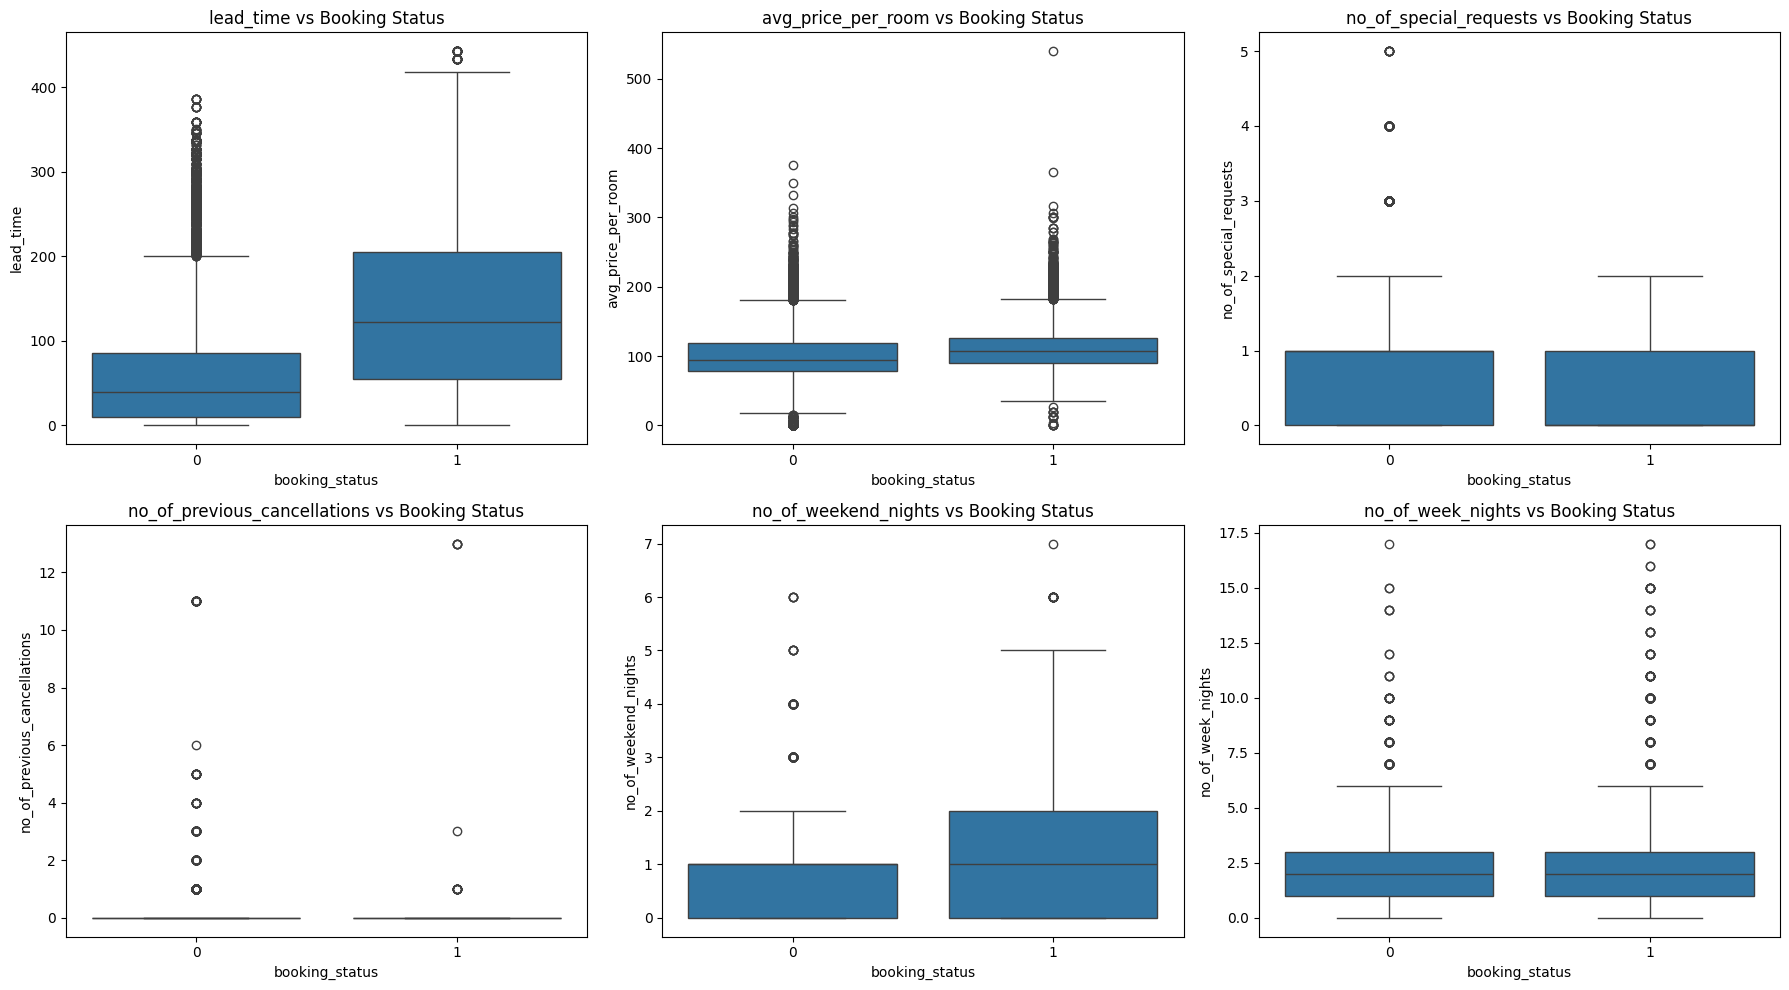

In [32]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(['lead_time', 'avg_price_per_room', 'no_of_special_requests',
                          'no_of_previous_cancellations', 'no_of_weekend_nights', 'no_of_week_nights']):
    sns.boxplot(x='booking_status', y=col, data=df2, ax=axes[i])
    axes[i].set_title(f'{col} vs Booking Status')
plt.tight_layout()
plt.show()


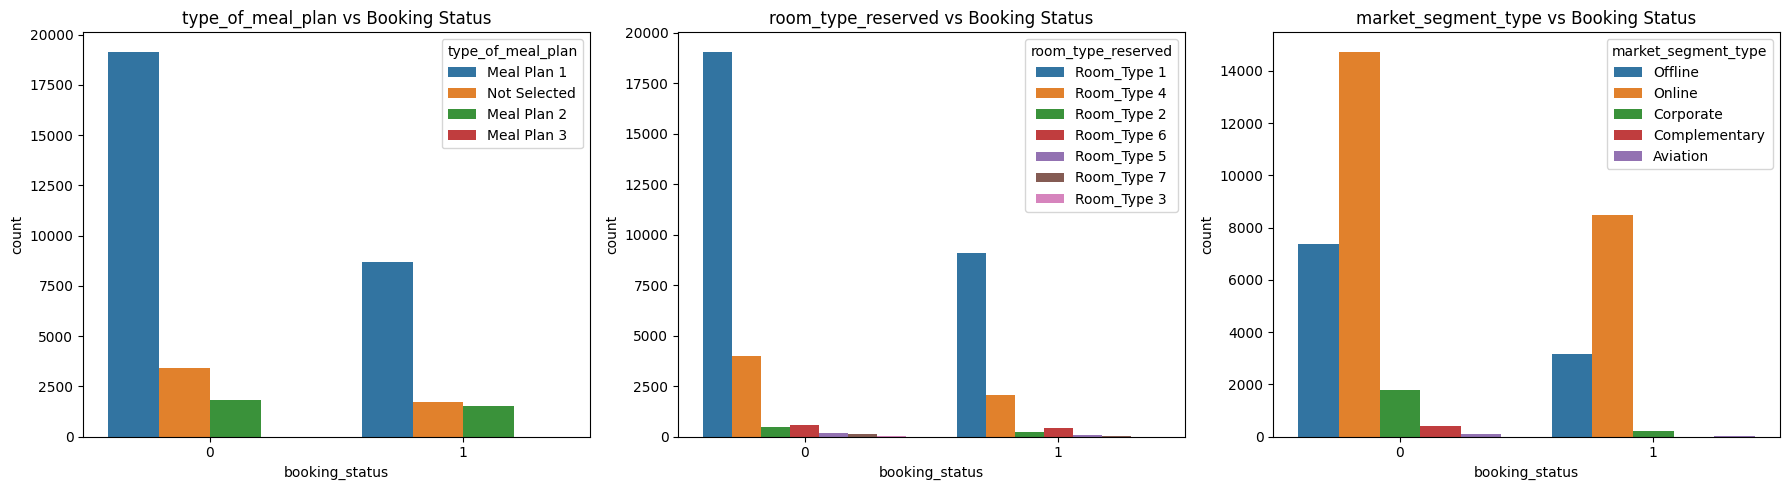

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_features_2):
    sns.countplot(x='booking_status', hue=col, data=df2, ax=axes[i])
    axes[i].set_title(f'{col} vs Booking Status')
plt.tight_layout()
plt.show()


In [34]:
X2 = df2.drop('booking_status', axis=1)
y2 = df2['booking_status']


In [35]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)


In [36]:
for col in numeric_features_2:
    if X2[col].isnull().any():
        X2_train[col] = X2_train[col].fillna(X2_train[col].mean())
        X2_test[col] = X2_test[col].fillna(X2_train[col].mean())

for col in categorical_features_2:
    if X2[col].isnull().any():
        X2_train[col] = X2_train[col].fillna(X2_train[col].mode()[0])
        X2_test[col] = X2_test[col].fillna(X2_train[col].mode()[0])

print("Missing values after fillna:", X2_train.isnull().sum().sum())


Missing values after fillna: 0


In [37]:
scaler2 = StandardScaler()
X2_train[numeric_features_2] = scaler2.fit_transform(X2_train[numeric_features_2])
X2_test[numeric_features_2] = scaler2.transform(X2_test[numeric_features_2])


In [38]:
encoder2 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder2.fit(X2_train[categorical_features_2])

X2_train_encoded = encoder2.transform(X2_train[categorical_features_2])
X2_test_encoded = encoder2.transform(X2_test[categorical_features_2])

encoded_cols2 = encoder2.get_feature_names_out(categorical_features_2)

X2_train_encoded = pd.DataFrame(X2_train_encoded, columns=encoded_cols2, index=X2_train.index)
X2_test_encoded = pd.DataFrame(X2_test_encoded, columns=encoded_cols2, index=X2_test.index)

X2_train = X2_train.drop(columns=categorical_features_2)
X2_test = X2_test.drop(columns=categorical_features_2)

X2_train = pd.concat([X2_train, X2_train_encoded], axis=1)
X2_test = pd.concat([X2_test, X2_test_encoded], axis=1)

print("X2_train shape:", X2_train.shape)
X2_train.head()


X2_train shape: (29020, 28)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_month,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Aviation,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
25629,0.300222,2.204559,1.373324,-0.856920,-0.181652,-0.691565,0.844278,-0.162657,-0.063513,-0.087032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
14473,0.300222,2.204559,0.221378,-0.856920,-0.181652,0.147033,-0.136113,-0.162657,-0.063513,-0.087032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
23720,0.300222,-0.262235,-0.930567,0.568823,-0.181652,4.048843,0.517481,-0.162657,-0.063513,-0.087032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5843,0.300222,-0.262235,1.373324,1.994567,-0.181652,1.276811,0.190684,-0.162657,-0.063513,-0.087032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18709,-1.627739,-0.262235,-0.930567,-0.144048,-0.181652,1.195281,-0.462910,-0.162657,-0.063513,-0.087032,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Logistic Regression – Dataset 2

Confusion Matrix:


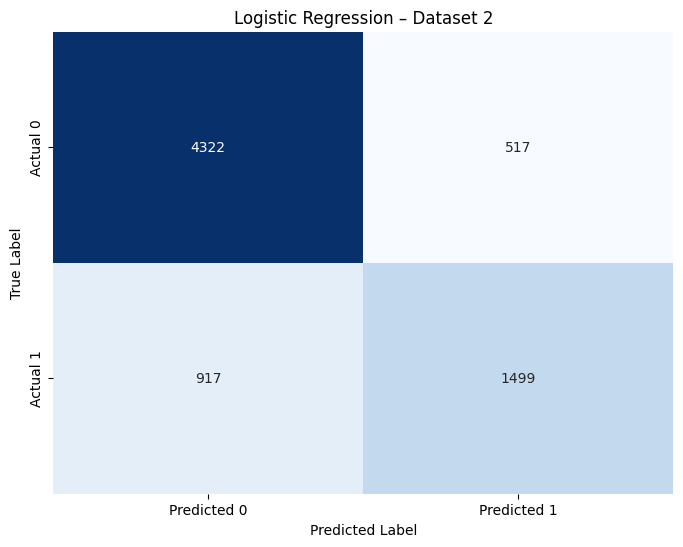

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      4839
           1       0.74      0.62      0.68      2416

    accuracy                           0.80      7255
   macro avg       0.78      0.76      0.77      7255
weighted avg       0.80      0.80      0.80      7255



In [39]:
lr2 = LogisticRegression(max_iter=1000)
lr2.fit(X2_train, y2_train)
y_pred_lr2 = lr2.predict(X2_test)

conf_mat(y2_test, y_pred_lr2, "Logistic Regression – Dataset 2")
print(classification_report(y2_test, y_pred_lr2))


## KNN – Dataset 2

Confusion Matrix:


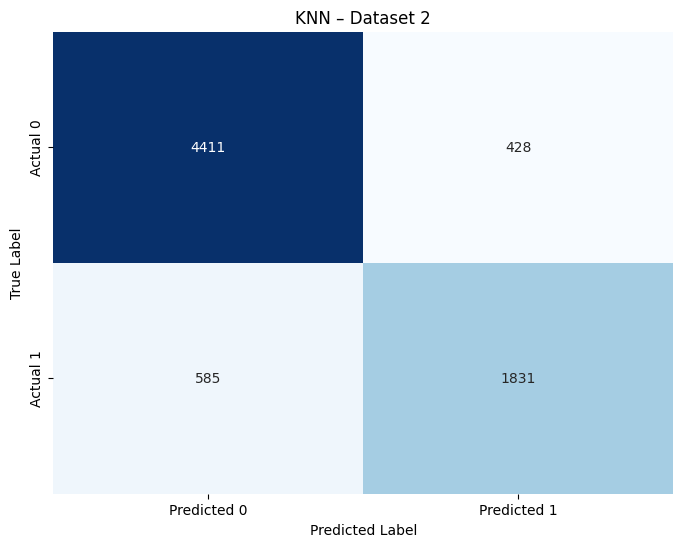

              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4839
           1       0.81      0.76      0.78      2416

    accuracy                           0.86      7255
   macro avg       0.85      0.83      0.84      7255
weighted avg       0.86      0.86      0.86      7255



In [40]:
knn2 = KNeighborsClassifier()
knn2.fit(X2_train, y2_train)
y_pred_knn2 = knn2.predict(X2_test)

conf_mat(y2_test, y_pred_knn2, "KNN – Dataset 2")
print(classification_report(y2_test, y_pred_knn2))


## Decision Tree – Dataset 2

Confusion Matrix:


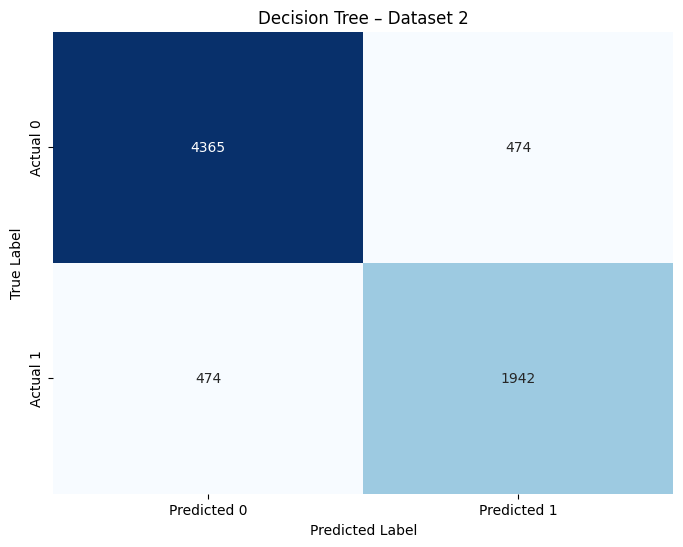

              precision    recall  f1-score   support

           0       0.90      0.90      0.90      4839
           1       0.80      0.80      0.80      2416

    accuracy                           0.87      7255
   macro avg       0.85      0.85      0.85      7255
weighted avg       0.87      0.87      0.87      7255



In [41]:
dt2 = DecisionTreeClassifier(random_state=42)
dt2.fit(X2_train, y2_train)
y_pred_dt2 = dt2.predict(X2_test)

conf_mat(y2_test, y_pred_dt2, "Decision Tree – Dataset 2")
print(classification_report(y2_test, y_pred_dt2))


## Random Forest – Dataset 2

Confusion Matrix:


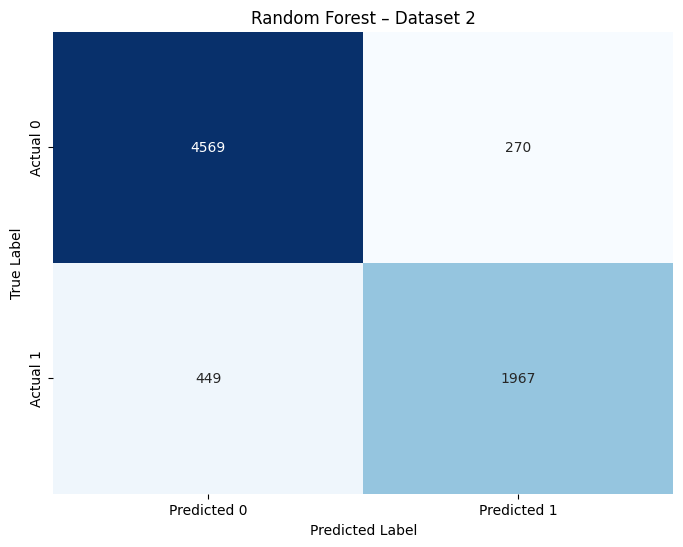

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      4839
           1       0.88      0.81      0.85      2416

    accuracy                           0.90      7255
   macro avg       0.89      0.88      0.89      7255
weighted avg       0.90      0.90      0.90      7255



In [42]:
rf2 = RandomForestClassifier(random_state=42)
rf2.fit(X2_train, y2_train)
y_pred_rf2 = rf2.predict(X2_test)

conf_mat(y2_test, y_pred_rf2, "Random Forest – Dataset 2")
print(classification_report(y2_test, y_pred_rf2))


## CNN – Dataset 2

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


907/907 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8002 - loss: 0.4396
Epoch 2/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8193 - loss: 0.4064
Epoch 3/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8263 - loss: 0.3935
Epoch 4/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8304 - loss: 0.3823
Epoch 5/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8341 - loss: 0.3736
Epoch 6/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8352 - loss: 0.3689
Epoch 7/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8398 - loss: 0.3629
Epoch 8/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8396 - loss: 0.3592
Epoch 9/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8420 - loss: 0.3542
Epoch 10/10
907/907 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8425 - loss: 0.3527
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:


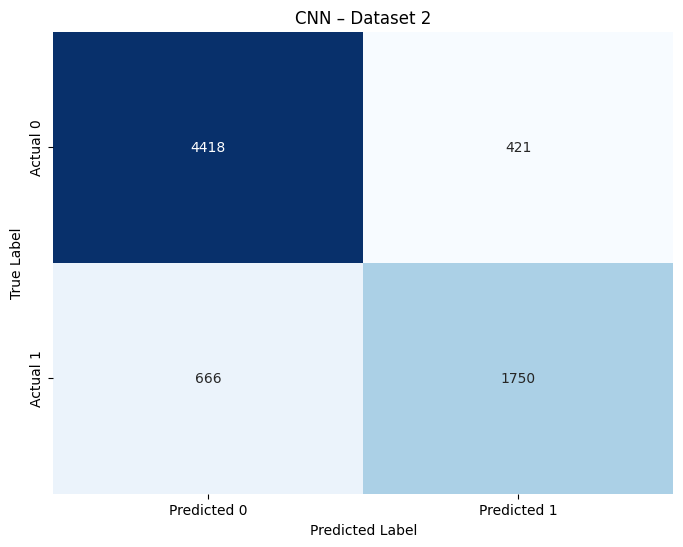

              precision    recall  f1-score   support

           0       0.87      0.91      0.89      4839
           1       0.81      0.72      0.76      2416

    accuracy                           0.85      7255
   macro avg       0.84      0.82      0.83      7255
weighted avg       0.85      0.85      0.85      7255



In [43]:

X2_train_cnn = np.array(X2_train).reshape(X2_train.shape[0], X2_train.shape[1], 1)
X2_test_cnn  = np.array(X2_test).reshape(X2_test.shape[0], X2_test.shape[1], 1)

# Build the CNN model
cnn2 = Sequential()
cnn2.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X2_train_cnn.shape[1], 1)))
cnn2.add(MaxPooling1D(pool_size=2))
cnn2.add(Flatten())
cnn2.add(Dense(64, activation='relu'))
cnn2.add(Dropout(0.3))
cnn2.add(Dense(1, activation='sigmoid'))

cnn2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn2.fit(X2_train_cnn, y2_train, epochs=10, batch_size=32, verbose=1)

y_pred_cnn2 = (cnn2.predict(X2_test_cnn) > 0.5).astype(int).flatten()

conf_mat(y2_test, y_pred_cnn2, 'CNN – Dataset 2')
print(classification_report(y2_test, y_pred_cnn2))


---
# Dataset 3: Hotel Cancellation

In [64]:
df3 = pd.read_csv("/content/Dataset 3.csv")
df3.head()


,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


In [65]:
print(df3.shape)
df3.info()


(36285, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64

In [67]:
numeric_features_3 = ['number of adults', 'number of children',
                      'number of weekend nights', 'number of week nights',
                      'car parking space', 'lead time', 'repeated',
                      'P-C', 'P-not-C', 'average price', 'special requests']

categorical_features_3 = ['type of meal', 'room type', 'market segment type']

In [68]:
df3.isnull().sum()


,0
Booking_ID,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0


In [69]:
df3.describe()


,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


## Data Cleaning – Dataset 3



In [70]:
df3.drop(['Booking_ID', 'date of reservation'], axis=1, inplace=True)

print("Shape after dropping:", df3.shape)
df3.head()

Shape after dropping: (36285, 15)


,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,booking status
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,Not_Canceled
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,Not_Canceled
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,Canceled
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,Canceled
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,Canceled


The target column booking status is text. We convert it to numbers: Canceled = 1, Not_Canceled = 0

In [71]:
df3['booking status'] = df3['booking status'].map({'Canceled': 1, 'Not_Canceled': 0})
print(df3['booking status'].value_counts())


booking status
0    24396
1    11889
Name: count, dtype: int64


In [73]:
df3.corr(numeric_only=True)


,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests,booking status
number of adults,1.000000,-0.020027,0.103316,0.105416,0.011467,0.097014,-0.192175,-0.047395,-0.119106,0.296832,0.189317,0.086774
number of children,-0.020027,1.000000,0.029536,0.024680,0.034198,-0.047058,-0.036371,-0.016398,-0.021201,0.337491,0.124363,0.033007
number of weekend nights,0.103316,0.029536,1.000000,0.179548,-0.031102,0.046510,-0.067096,-0.020687,-0.026307,-0.004565,0.060432,0.061489
number of week nights,0.105416,0.024680,0.179548,1.000000,-0.048814,0.149600,-0.099782,-0.030089,-0.049354,0.022751,0.046136,0.092824
car parking space,0.011467,0.034198,-0.031102,-0.048814,1.000000,-0.066444,0.110916,0.027109,0.063814,0.061310,0.087889,-0.086179
lead time,0.097014,-0.047058,0.046510,0.149600,-0.066444,1.000000,-0.135966,-0.045718,-0.078126,-0.062578,-0.101604,0.438491
repeated,-0.192175,-0.036371,-0.067096,-0.099782,0.110916,-0.135966,1.000000,0.390811,0.539157,-0.174881,-0.011834,-0.107277
P-C,-0.047395,-0.016398,-0.020687,-0.030089,0.027109,-0.045718,0.390811,1.000000,0.468148,-0.063334,-0.003323,-0.033725
P-not-C,-0.119106,-0.021201,-0.026307,-0.049354,0.063814,-0.078126,0.539157,0.468148,1.000000,-0.113673,0.027363,-0.060174
average price,0.296832,0.337491,-0.004565,0.022751,0.061310,-0.062578,-0.174881,-0.063334,-0.113673,1.000000,0.184468,0.142433


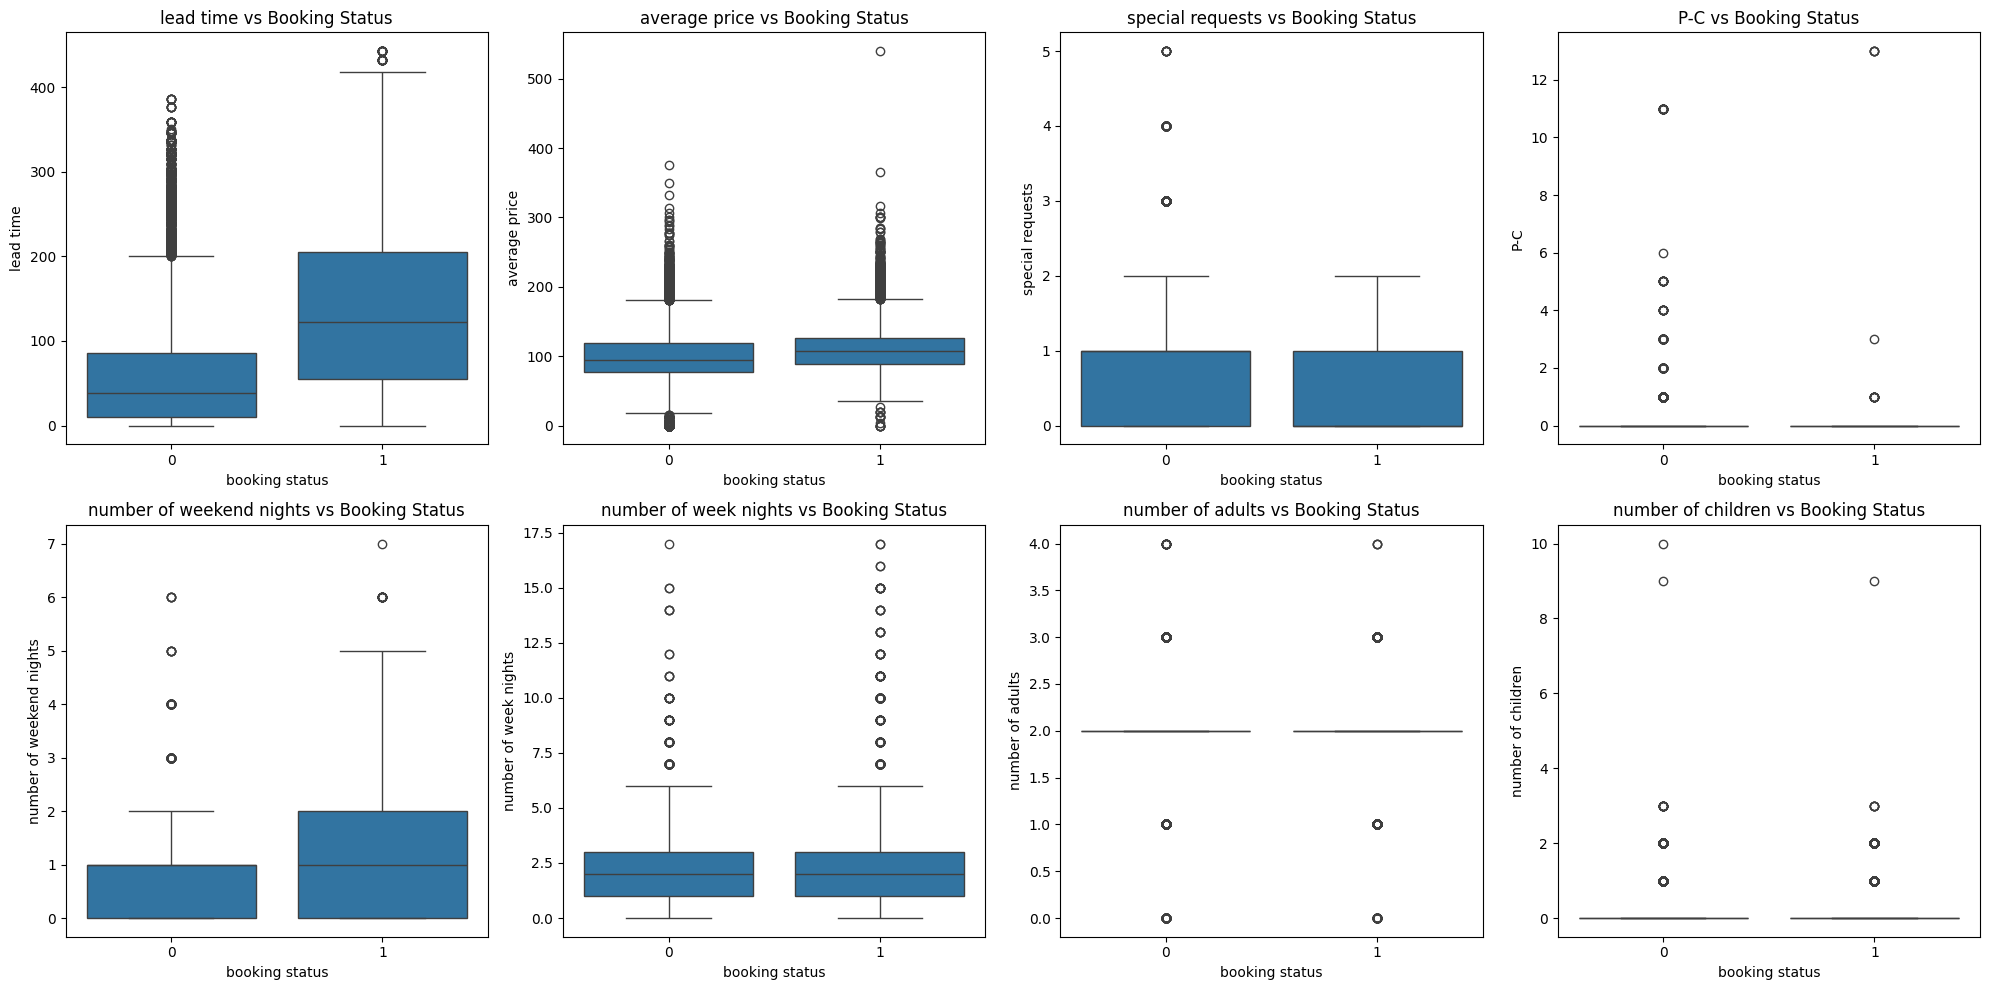

In [74]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()
for i, col in enumerate(['lead time', 'average price', 'special requests',
                          'P-C', 'number of weekend nights', 'number of week nights',
                          'number of adults', 'number of children']):
    sns.boxplot(x='booking status', y=col, data=df3, ax=axes[i])
    axes[i].set_title(f'{col} vs Booking Status')
plt.tight_layout()
plt.show()


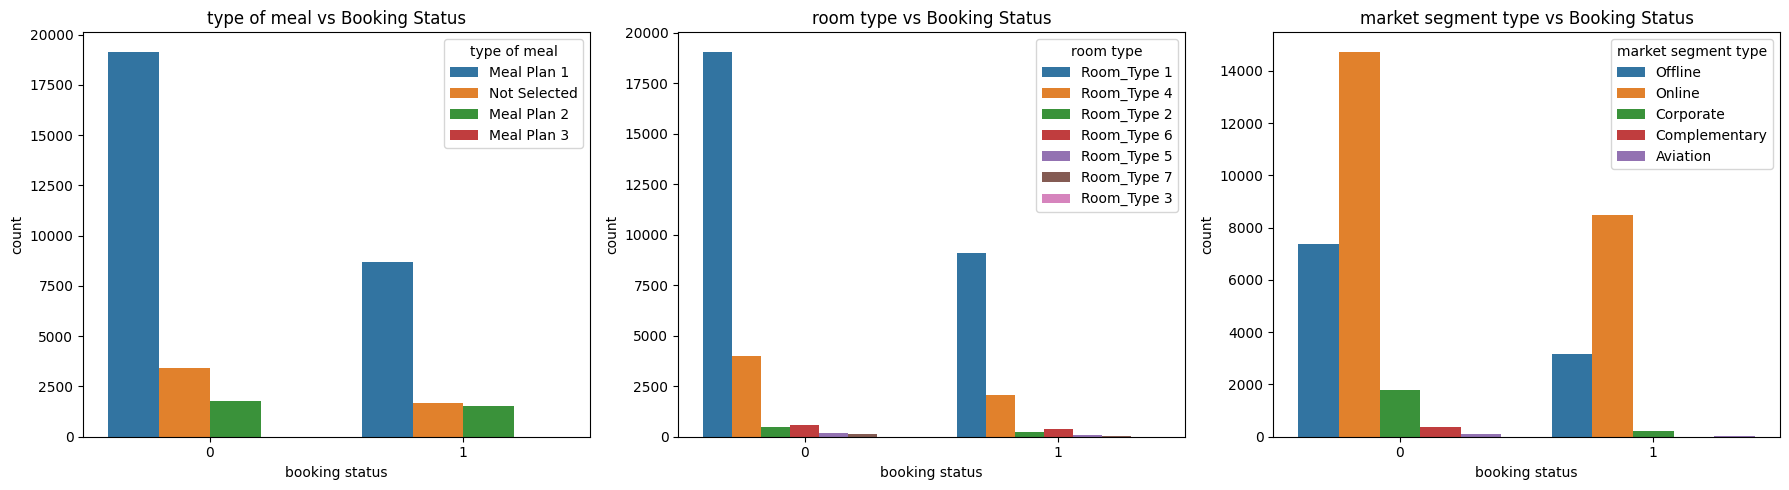

In [75]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(categorical_features_3):
    sns.countplot(x='booking status', hue=col, data=df3, ax=axes[i])
    axes[i].set_title(f'{col} vs Booking Status')
plt.tight_layout()
plt.show()



In [76]:
X3 = df3.drop('booking status', axis=1)
y3 = df3['booking status']



In [77]:
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)


In [78]:
for col in numeric_features_3:
    if X3[col].isnull().any():
        X3_train[col] = X3_train[col].fillna(X3_train[col].mean())
        X3_test[col] = X3_test[col].fillna(X3_train[col].mean())

for col in categorical_features_3:
    if X3[col].isnull().any():
        X3_train[col] = X3_train[col].fillna(X3_train[col].mode()[0])
        X3_test[col] = X3_test[col].fillna(X3_train[col].mode()[0])

print("Missing values after fillna:", X3_train.isnull().sum().sum())


Missing values after fillna: 0


In [79]:
scaler3 = StandardScaler()
X3_train[numeric_features_3] = scaler3.fit_transform(X3_train[numeric_features_3])
X3_test[numeric_features_3] = scaler3.transform(X3_test[numeric_features_3])


In [80]:
encoder3 = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder3.fit(X3_train[categorical_features_3])

X3_train_encoded = encoder3.transform(X3_train[categorical_features_3])
X3_test_encoded = encoder3.transform(X3_test[categorical_features_3])

encoded_cols3 = encoder3.get_feature_names_out(categorical_features_3)

X3_train_encoded = pd.DataFrame(X3_train_encoded, columns=encoded_cols3, index=X3_train.index)
X3_test_encoded = pd.DataFrame(X3_test_encoded, columns=encoded_cols3, index=X3_test.index)

X3_train = X3_train.drop(columns=categorical_features_3)
X3_test = X3_test.drop(columns=categorical_features_3)

X3_train = pd.concat([X3_train, X3_train_encoded], axis=1)
X3_test = pd.concat([X3_test, X3_test_encoded], axis=1)

print("X3_train shape:", X3_train.shape)


X3_train shape: (29028, 27)


## Logistic Regression – Dataset 3

Confusion Matrix:


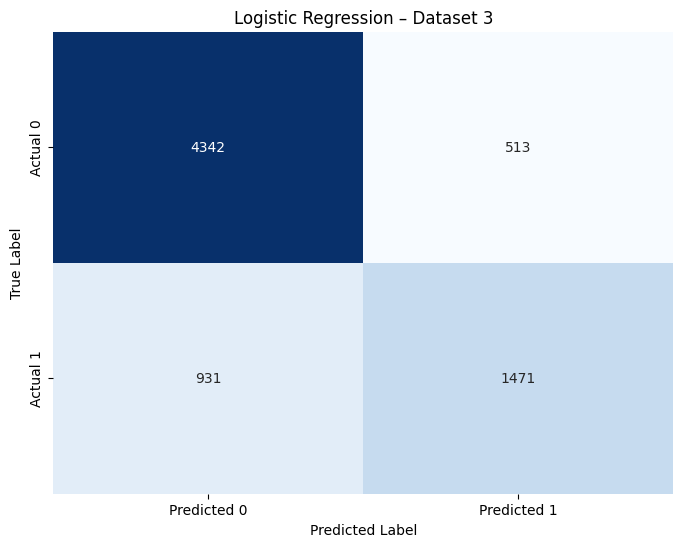

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      4855
           1       0.74      0.61      0.67      2402

    accuracy                           0.80      7257
   macro avg       0.78      0.75      0.76      7257
weighted avg       0.80      0.80      0.80      7257



In [81]:
lr3 = LogisticRegression(max_iter=1000)
lr3.fit(X3_train, y3_train)
y_pred_lr3 = lr3.predict(X3_test)

conf_mat(y3_test, y_pred_lr3, "Logistic Regression – Dataset 3")
print(classification_report(y3_test, y_pred_lr3))


## KNN – Dataset 3

Confusion Matrix:


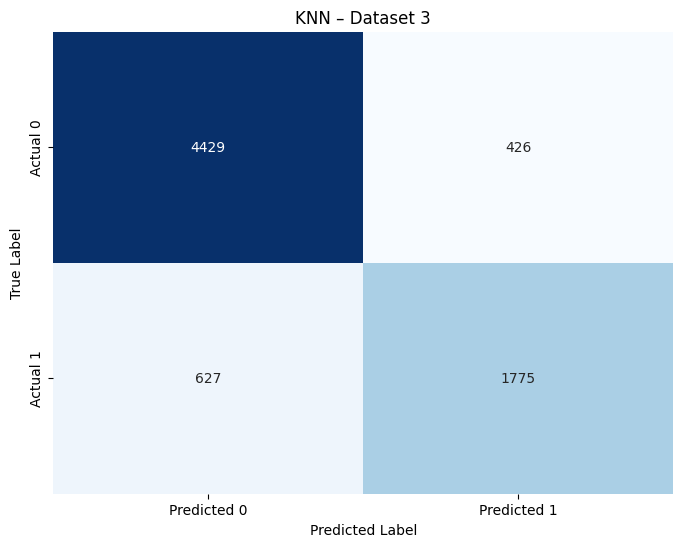

              precision    recall  f1-score   support

           0       0.88      0.91      0.89      4855
           1       0.81      0.74      0.77      2402

    accuracy                           0.85      7257
   macro avg       0.84      0.83      0.83      7257
weighted avg       0.85      0.85      0.85      7257



In [82]:
knn3 = KNeighborsClassifier()
knn3.fit(X3_train, y3_train)
y_pred_knn3 = knn3.predict(X3_test)

conf_mat(y3_test, y_pred_knn3, "KNN – Dataset 3")
print(classification_report(y3_test, y_pred_knn3))


## Decision Tree – Dataset 3

Confusion Matrix:


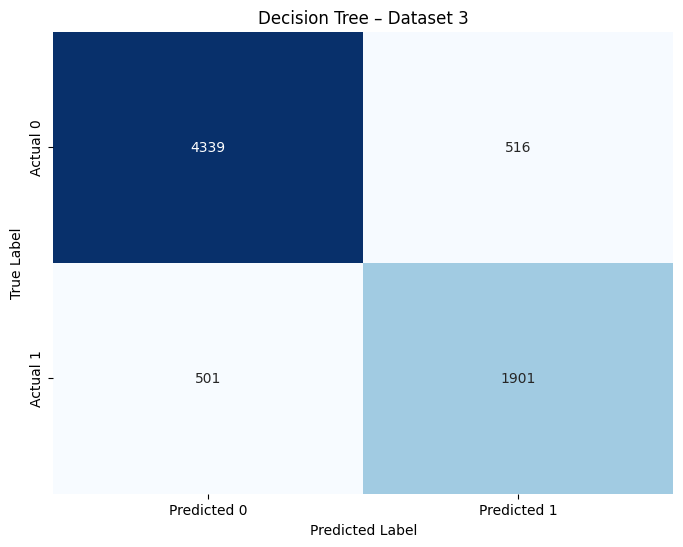

              precision    recall  f1-score   support

           0       0.90      0.89      0.90      4855
           1       0.79      0.79      0.79      2402

    accuracy                           0.86      7257
   macro avg       0.84      0.84      0.84      7257
weighted avg       0.86      0.86      0.86      7257



In [83]:
dt3 = DecisionTreeClassifier(random_state=42)
dt3.fit(X3_train, y3_train)
y_pred_dt3 = dt3.predict(X3_test)

conf_mat(y3_test, y_pred_dt3, "Decision Tree – Dataset 3")
print(classification_report(y3_test, y_pred_dt3))


## Random Forest – Dataset 3

Confusion Matrix:


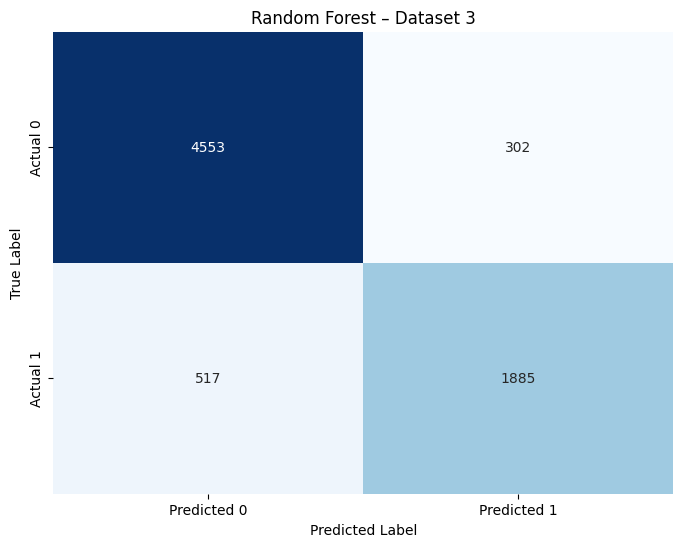

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4855
           1       0.86      0.78      0.82      2402

    accuracy                           0.89      7257
   macro avg       0.88      0.86      0.87      7257
weighted avg       0.89      0.89      0.89      7257



In [84]:
rf3 = RandomForestClassifier(random_state=42)
rf3.fit(X3_train, y3_train)
y_pred_rf3 = rf3.predict(X3_test)

conf_mat(y3_test, y_pred_rf3, "Random Forest – Dataset 3")
print(classification_report(y3_test, y_pred_rf3))


## CNN – Dataset 3

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


908/908 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7979 - loss: 0.4399
Epoch 2/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8167 - loss: 0.4089
Epoch 3/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8227 - loss: 0.3994
Epoch 4/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8271 - loss: 0.3910
Epoch 5/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8305 - loss: 0.3844
Epoch 6/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8328 - loss: 0.3798
Epoch 7/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8359 - loss: 0.3761
Epoch 8/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8368 - loss: 0.3720
Epoch 9/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8353 - loss: 0.3705
Epoch 10/10
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8391 - loss: 0.3673
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:


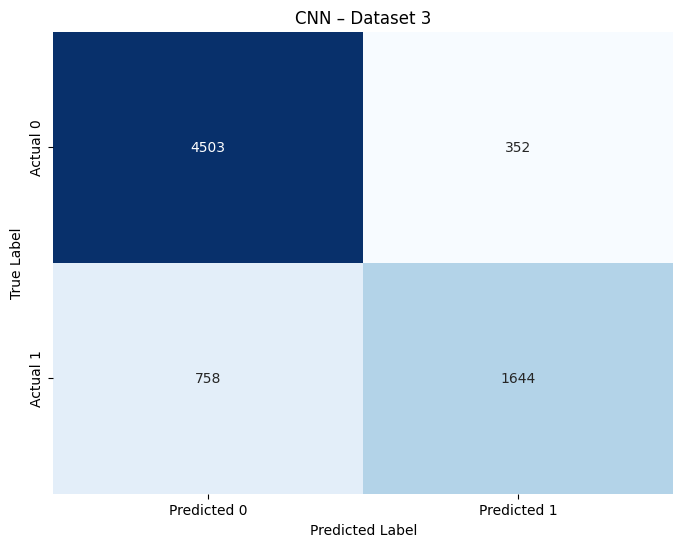

              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4855
           1       0.82      0.68      0.75      2402

    accuracy                           0.85      7257
   macro avg       0.84      0.81      0.82      7257
weighted avg       0.85      0.85      0.84      7257



In [85]:

X3_train_cnn = np.array(X3_train).reshape(X3_train.shape[0], X3_train.shape[1], 1)
X3_test_cnn  = np.array(X3_test).reshape(X3_test.shape[0], X3_test.shape[1], 1)

# Build the CNN model
cnn3 = Sequential()
cnn3.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X3_train_cnn.shape[1], 1)))
cnn3.add(MaxPooling1D(pool_size=2))
cnn3.add(Flatten())
cnn3.add(Dense(64, activation='relu'))
cnn3.add(Dropout(0.3))
cnn3.add(Dense(1, activation='sigmoid'))

cnn3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
cnn3.fit(X3_train_cnn, y3_train, epochs=10, batch_size=32, verbose=1)

y_pred_cnn3 = (cnn3.predict(X3_test_cnn) > 0.5).astype(int).flatten()

conf_mat(y3_test, y_pred_cnn3, 'CNN – Dataset 3')
print(classification_report(y3_test, y_pred_cnn3))


---
# Summary of Results

The table below summarizes the accuracy of each model on each dataset.

In [86]:
from sklearn.metrics import accuracy_score

results = {
    'Algorithm': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest', 'CNN'],
    'Dataset 1': [
        round(accuracy_score(y1_test, y_pred_lr1), 4),
        round(accuracy_score(y1_test, y_pred_knn1), 4),
        round(accuracy_score(y1_test, y_pred_dt1), 4),
        round(accuracy_score(y1_test, y_pred_rf1), 4),
        round(accuracy_score(y1_test, y_pred_cnn1), 4),
    ],
    'Dataset 2': [
        round(accuracy_score(y2_test, y_pred_lr2), 4),
        round(accuracy_score(y2_test, y_pred_knn2), 4),
        round(accuracy_score(y2_test, y_pred_dt2), 4),
        round(accuracy_score(y2_test, y_pred_rf2), 4),
        round(accuracy_score(y2_test, y_pred_cnn2), 4),
    ],
    'Dataset 3': [
        round(accuracy_score(y3_test, y_pred_lr3), 4),
        round(accuracy_score(y3_test, y_pred_knn3), 4),
        round(accuracy_score(y3_test, y_pred_dt3), 4),
        round(accuracy_score(y3_test, y_pred_rf3), 4),
        round(accuracy_score(y3_test, y_pred_cnn3), 4),
    ],
}

summary_df = pd.DataFrame(results)
summary_df.set_index('Algorithm', inplace=True)
print(summary_df.to_string())


                     Dataset 1  Dataset 2  Dataset 3
Algorithm                                           
Logistic Regression     0.8177     0.8023     0.8010
KNN                     0.8241     0.8604     0.8549
Decision Tree           0.8298     0.8693     0.8599
Random Forest           0.8707     0.9009     0.8871
CNN                     0.8526     0.8502     0.8470
